In [1]:
import mediapipe
print("Version actuelle de MediaPipe :", mediapipe.__version__)

Version actuelle de MediaPipe : 0.10.33


# **Verification image**

-Je vais commencer par une 1er vification des images du DATASET pris sur Kaggle

-J'utiliserai le models Mediapipe (google) pour verifier la détection d'image

-pour ce faire j'ai utilisé le models short_range (Modèle léger permettant de détecter un ou plusieurs visages dans des images de type selfie prises avec un appareil photo de smartphone ou une webcam)

In [18]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from pathlib import Path
import shutil

# 1. On indique simplement le nom du fichier que tu viens de télécharger
# Attention : vérifie si ton fichier fini par .tflite ou .task et corrige cette ligne si besoin
# Remplace ton ancienne ligne par celle-ci :
model_path = r'C:\Users\Mfumu\Documents\skinmatch\blaze_face_short_range.tflite'

def filter_face_images(input_dir, output_dir, rejected_dir):
    """
    Garde uniquement les images contenant un visage détectable.
    Déplace les rejetées dans rejected_dir pour audit manuel.
    """
    # 2. Configuration de la nouvelle API
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceDetectorOptions(base_options=base_options, min_detection_confidence=0.5)

    # 3. Gestion des dossiers
    input_dir  = Path(input_dir)
    output_dir = Path(output_dir)
    rejected_dir = Path(rejected_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    rejected_dir.mkdir(parents=True, exist_ok=True)

    kept, rejected = 0, 0

    # 4. Lancement du détecteur
    with vision.FaceDetector.create_from_options(options) as detector:
        
        extensions_valides = ['.jpg', '.jpeg', '.png']
        images_trouvees = [p for p in input_dir.iterdir() if p.suffix.lower() in extensions_valides]
        
        for img_path in images_trouvees:
            try:
                mp_image = mp.Image.create_from_file(str(img_path))
                detection_result = detector.detect(mp_image)

                if len(detection_result.detections) > 0:
                    shutil.copy(img_path, output_dir / img_path.name)
                    kept += 1
                else:
                    shutil.copy(img_path, rejected_dir / img_path.name)
                    rejected += 1
                    
            except Exception as e:
                print(f"Erreur de lecture sur {img_path.name}, image rejetée.")
                shutil.copy(img_path, rejected_dir / img_path.name)
                rejected += 1

    # 5. Affichage des résultats
    print("-" * 30)
    print(f"Images gardées  : {kept}")
    print(f"Images rejetées : {rejected}")
    
    if (kept + rejected) > 0:
        print(f"Taux de rétention : {kept/(kept+rejected)*100:.1f}%")
    else:
        print("⚠️ Aucune image .jpg n'a été trouvée dans le dossier d'entrée !")

# Usage
filter_face_images(
    input_dir   = r"C:\Users\Mfumu\Documents\skinmatch\data\raw\skin_images\acne",
    output_dir  = r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images_clean\acne",
    rejected_dir= r"C:\Users\Mfumu\Documents\skinmatch\data\raw\skin_images\acne_rejected"
)


------------------------------
Images gardées  : 709
Images rejetées : 958
Taux de rétention : 42.5%


# **Verification image**

Apres un 1er tri d'image, j'ai voulu verifier physiquement les photo garder.
-Apres verification , il a fallu faire un tri manuellement sur certaine image ce qui m'a amené a ce nouveau score

In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from pathlib import Path
import shutil

# 1. On indique simplement le nom du fichier que tu viens de télécharger
# Attention : vérifie si ton fichier fini par .tflite ou .task et corrige cette ligne si besoin
# Remplace ton ancienne ligne par celle-ci :
model_path = r'C:\Users\Mfumu\Documents\skinmatch\blaze_face_short_range.tflite'

def filter_face_images(input_dir, output_dir, rejected_dir):
    """
    Garde uniquement les images contenant un visage détectable.
    Déplace les rejetées dans rejected_dir pour audit manuel.
    """
    # 2. Configuration de la nouvelle API
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceDetectorOptions(base_options=base_options, min_detection_confidence=0.5)

    # 3. Gestion des dossiers
    input_dir  = Path(input_dir)
    output_dir = Path(output_dir)
    rejected_dir = Path(rejected_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    rejected_dir.mkdir(parents=True, exist_ok=True)

    kept, rejected = 0, 0

    # 4. Lancement du détecteur
    with vision.FaceDetector.create_from_options(options) as detector:
        
        extensions_valides = ['.jpg', '.jpeg', '.png']
        images_trouvees = [p for p in input_dir.iterdir() if p.suffix.lower() in extensions_valides]
        
        for img_path in images_trouvees:
            try:
                mp_image = mp.Image.create_from_file(str(img_path))
                detection_result = detector.detect(mp_image)

                if len(detection_result.detections) > 0:
                    shutil.copy(img_path, output_dir / img_path.name)
                    kept += 1
                else:
                    shutil.copy(img_path, rejected_dir / img_path.name)
                    rejected += 1
                    
            except Exception as e:
                print(f"Erreur de lecture sur {img_path.name}, image rejetée.")
                shutil.copy(img_path, rejected_dir / img_path.name)
                rejected += 1

    # 5. Affichage des résultats
    print("-" * 30)
    print(f"Images gardées  : {kept}")
    print(f"Images rejetées : {rejected}")
    
    if (kept + rejected) > 0:
        print(f"Taux de rétention : {kept/(kept+rejected)*100:.1f}%")
    else:
        print("⚠️ Aucune image .jpg n'a été trouvée dans le dossier d'entrée !")

# Usage
filter_face_images(
    input_dir   = r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images_clean\acne",
    output_dir  = r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images_clean\acne2",
    rejected_dir= r"C:\Users\Mfumu\Documents\skinmatch\data\raw\skin_images\acne_rejected1"
)


------------------------------
Images gardées  : 629
Images rejetées : 4
Taux de rétention : 99.4%


# **Analyse des dimensions**



Extraction des dimensions en cours...


100%|██████████| 629/629 [00:00<00:00, 3500.86it/s]


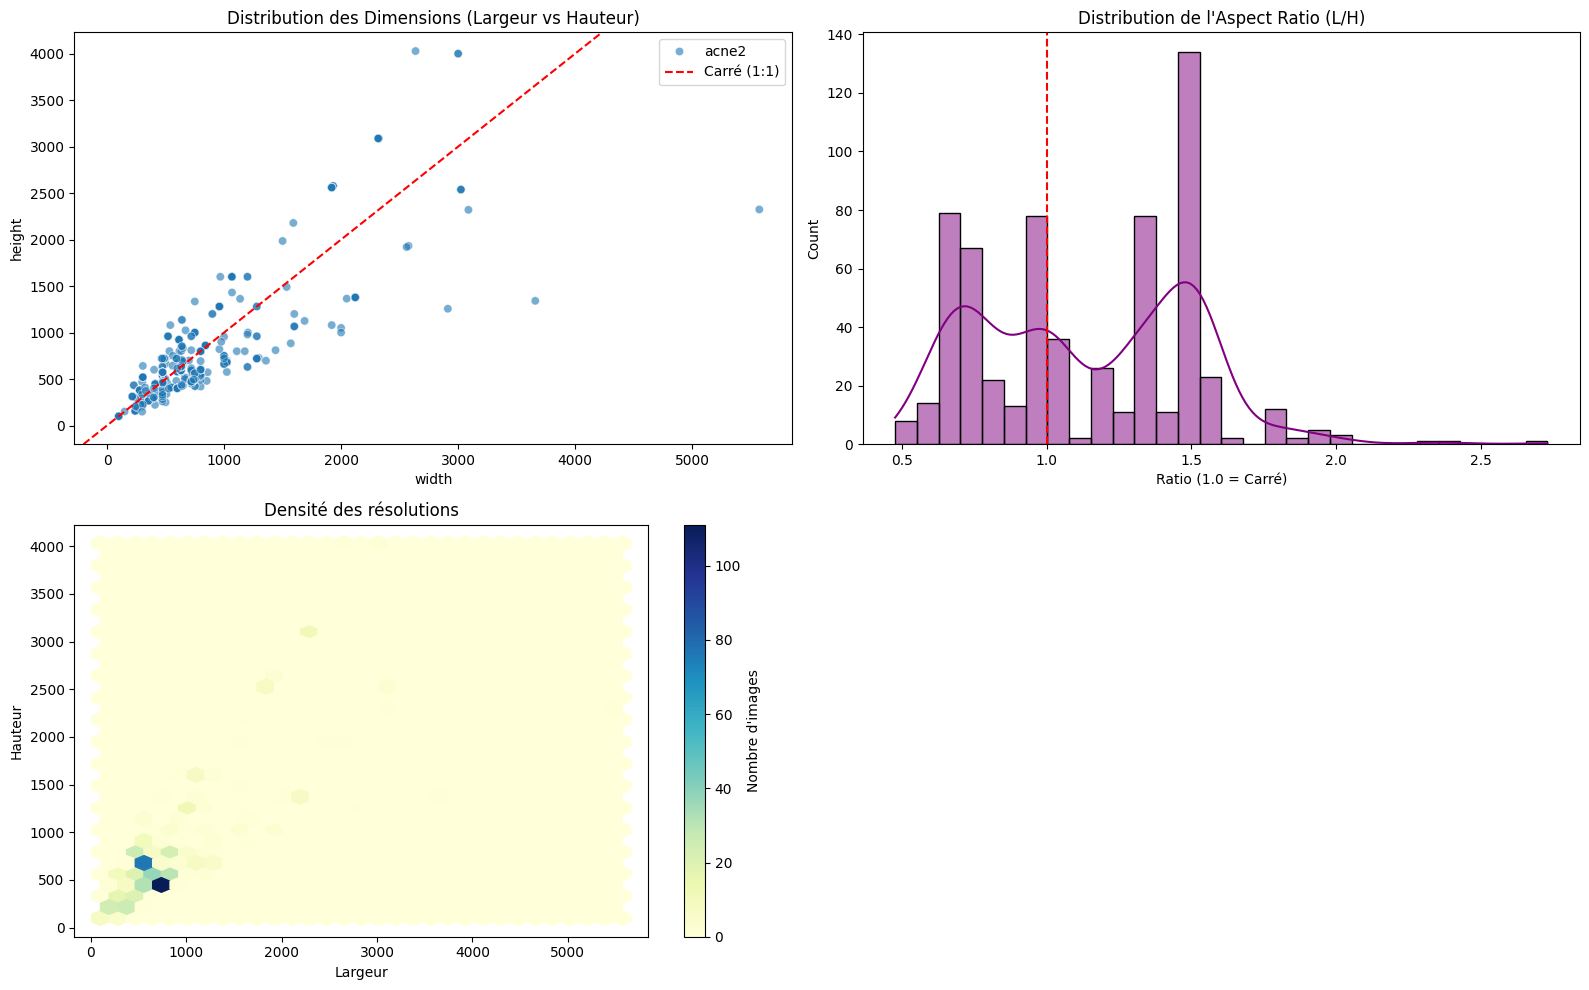


--- Statistiques des Dimensions ---
             width       height  aspect_ratio
count   629.000000   629.000000    629.000000
mean    765.826709   734.260731      1.135949
std     549.510289   587.082519      0.365092
min     100.000000   100.000000      0.477379
25%     475.000000   472.000000      0.751295
50%     647.000000   600.000000      1.067568
75%     800.000000   720.000000      1.500000
max    5573.000000  4028.000000      2.728561


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

def analyze_image_dimensions(dataset_path):
    data = []
    
    # Extensions d'images acceptées
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    
    print("Extraction des dimensions en cours...")
    for root, dirs, files in os.walk(dataset_path):
        for file in tqdm(files):
            if file.lower().endswith(valid_extensions):
                img_path = os.path.join(root, file)
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        # On récupère le nom du dossier parent comme label de classe
                        label = os.path.basename(root)
                        data.append({
                            'filename': file,
                            'width': width,
                            'height': height,
                            'aspect_ratio': width / height,
                            'area': width * height,
                            'class': label
                        })
                except Exception as e:
                    print(f"Erreur sur {file}: {e}")

    return pd.DataFrame(data)

# --- 1. Extraction ---
# Remplace par ton chemin local vers le dataset acné
path_to_data =r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images_clean\acne2"
df = analyze_image_dimensions(path_to_data)

# --- 2. Visualisations ---
plt.figure(figsize=(16, 10))

# Graphique A : Nuage de points (Scatter Plot) des dimensions
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='width', y='height', hue='class', alpha=0.6)
plt.title('Distribution des Dimensions (Largeur vs Hauteur)')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='Carré (1:1)')
plt.legend()

# Graphique B : Distribution des Aspect Ratios
plt.subplot(2, 2, 2)
sns.histplot(df['aspect_ratio'], bins=30, kde=True, color='purple')
plt.axvline(1.0, color='red', linestyle='--')
plt.title("Distribution de l'Aspect Ratio (L/H)")
plt.xlabel('Ratio (1.0 = Carré)')


# Graphique D : Heatmap de densité des résolutions
plt.subplot(2, 2, 3)
plt.hexbin(df['width'], df['height'], gridsize=30, cmap='YlGnBu')
plt.colorbar(label='Nombre d\'images')
plt.title('Densité des résolutions')
plt.xlabel('Largeur')
plt.ylabel('Hauteur')

plt.tight_layout()
plt.show()

# --- 3. Statistiques descriptives ---
print("\n--- Statistiques des Dimensions ---")
print(df[['width', 'height', 'aspect_ratio']].describe())

**Distribution des dimension:**

-Comme en peut voir sur le grah on aucune image d'un carré parfait 

-Il y a des points très à droite (images très larges, format panoramique)

-un redimensionnement sera necessaire

**Distrubiton du ration (H/L):**

-on peut voir que l'on a pique sur la repartion d'image en fromat portrait (0,6-0,7) ,(1) format carré et (1,5) format paysage/panoramique

-cela montre que l'on a un melange de source d'image (portable , web , webcam et appareil photo)

**Distribution de la résolution:**

-on peut q'un bonne partie des images sont en dessous de la 800 x 800

-on peut voir que notre centre de gravité la tache blue noire qui est le plus représenté se situe au alentour de 600x800

In [ ]:
import os
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import shutil

def filter_extreme_dimensions(source_dir, n_extremes=10 , n_extremes2=4):
    """
    Identifie et déplace les N plus grandes et N plus petites images en termes de surface.
    """
    source_path = Path(source_dir)
    rejected_path = source_path.parent / "rejected_outliers"
    rejected_path.mkdir(exist_ok=True)
    
    data = []
    extensions = {'.jpg', '.jpeg', '.png'}
    
    print(f"--- Phase 1 : Analyse des dimensions ---")
    all_files = [p for p in source_path.rglob('*') if p.suffix.lower() in extensions]
    
    for img_path in tqdm(all_files):
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                data.append({
                    'path': img_path,
                    'name': img_path.name,
                    'width': w,
                    'height': h,
                    'area': w * h
                })
        except Exception as e:
            print(f"Erreur lecture {img_path.name}: {e}")

    df = pd.DataFrame(data)
    
    # 1. Identifier les plus petites (Tri croissant)
    smallest = df.nsmallest(n_extremes, 'area')
    
    # 2. Identifier les plus grandes (Tri décroissant)
    largest = df.nlargest(n_extremes2, 'area')
    
    to_reject = pd.concat([smallest])
    
    print(f"\n--- Phase 2 : Rejet de {len(to_reject)} images ---")
    
    for idx, row in to_reject.iterrows():
        img_src = row['path']
        # On crée un nom de fichier qui indique pourquoi il est rejeté
        reason = "SMALL" if row['area'] in smallest['area'].values else "LARGE"
        dest_name = f"{reason}_{row['width']}x{row['height']}_{img_src.name}"
        dest_path = rejected_path / dest_name
        
        try:
            # Déplacement du fichier
            shutil.move(str(img_src), str(dest_path))
            print(f"Rejeté ({reason}) : {img_src.name} [{row['width']}x{row['height']}]")
        except Exception as e:
            print(f"Erreur lors du déplacement de {img_src.name}: {e}")

    print(f"\n✅ Terminé ! Les images ont été déplacées vers : {rejected_path}")

# --- CONFIGURATION ---
# Utilise le chemin de ton dossier de données
MON_DOSSIER = r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images_clean\acne2"

# Lancement (on rejette les 10 plus petites et 10 plus grandes)
filter_extreme_dimensions(MON_DOSSIER, n_extremes=10)

--- Phase 1 : Analyse des dimensions ---


100%|██████████| 629/629 [00:00<00:00, 14158.69it/s]


--- Phase 2 : Rejet de 10 images ---
Rejeté (SMALL) : 2 (4).jpeg [100x100]
Rejeté (SMALL) : 2 (7).jpeg [100x100]
Rejeté (SMALL) : pigmentation_0_1307.jpeg [100x100]
Rejeté (SMALL) : pigmentation_0_1997.jpeg [100x100]
Rejeté (SMALL) : pigmentation_0_3271.jpeg [100x100]
Rejeté (SMALL) : pigmentation_0_4629.jpeg [100x100]
Rejeté (SMALL) : pigmentation_0_8864.jpeg [100x100]
Rejeté (SMALL) : pigmentation_0_3762.jpeg [150x150]
Rejeté (SMALL) : pigmentation_0_1281.jpeg [240x157]
Rejeté (SMALL) : pigmentation_0_6175.jpeg [240x157]

✅ Terminé ! Les images ont été déplacées vers : C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images_clean\rejected_outliers


Apres analyse des dimension 

# **Redimensionnemnt des Image**
Nous allons utiliser un LetterBoxing pour redimensionner les images . Cette methode permet de redimensionner l'image sans déformation et perte d'information de l'image.
Tu redimensionnes l'image pour que son côté le plus long atteigne ta taille cible (par exemple 512 ou 640), et tu combles l'espace vide restant avec des bandes noires pour obtenir un carré

In [12]:
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# 1. On remet la fonction de letterbox ici pour que le script soit complet
def letterbox_image(image_path, target_size=(640, 640), background_color=(0, 0, 0)):
    image = Image.open(image_path)
    # Convertir en RGB si l'image est en RGBA (transparent) ou L (noir et blanc)
    if image.mode != "RGB":
        image = image.convert("RGB")
        
    image.thumbnail(target_size, Image.Resampling.LANCZOS)
    new_image = Image.new("RGB", target_size, background_color)
    x_offset = (target_size[0] - image.size[0]) // 2
    y_offset = (target_size[1] - image.size[1]) // 2
    new_image.paste(image, (x_offset, y_offset))
    return new_image

# 2. La fonction pour traiter tout le dossier
def process_dataset(input_dir, output_dir, target_size=(640, 640)):
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    
    # On cherche toutes les images, y compris dans les sous-dossiers (rglob)
    extensions_valides = {'.jpg', '.jpeg', '.png'}
    toutes_les_images = [p for p in input_path.rglob('*') if p.suffix.lower() in extensions_valides]
    
    print(f"🔍 {len(toutes_les_images)} images trouvées. Début du traitement...")
    
    # On boucle sur chaque image avec une barre de progression
    for img_path in tqdm(toutes_les_images, desc="Letterboxing"):
        # Astuce : On garde la structure des dossiers !
        # Exemple : "dataset/train/acne/img1.jpg" -> "train/acne/img1.jpg"
        chemin_relatif = img_path.relative_to(input_path)
        chemin_sortie = output_path / chemin_relatif
        
        # On crée les sous-dossiers de sortie s'ils n'existent pas
        chemin_sortie.parent.mkdir(parents=True, exist_ok=True)
        
        try:
            # Traitement
            img_redimensionnee = letterbox_image(str(img_path), target_size=target_size)
            # Sauvegarde
            img_redimensionnee.save(str(chemin_sortie))
        except Exception as e:
            print(f"\n⚠️ Erreur lors du traitement de {img_path.name} : {e}")

    print(f"\n✅ Terminé ! Le dataset formaté se trouve dans : {output_path}")

# --- 3. Exécution ---

# Modifie ces deux chemins selon ton ordinateur
DOSSIER_ORIGINE = r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images_clean\acne2"
DOSSIER_SORTIE = r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images\acne_size"

# Lancement du script
process_dataset(DOSSIER_ORIGINE, DOSSIER_SORTIE, target_size=(640, 640))

🔍 619 images trouvées. Début du traitement...


Letterboxing: 100%|██████████| 619/619 [00:06<00:00, 101.94it/s]


✅ Terminé ! Le dataset formaté se trouve dans : C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images\acne_size


## **Redimensionnement et conversion**:

- Le redimensionnement en 640x640 c'est fait avec succes sur l'ensemble des images gardé sont déformer l'image

- Nous avons aussi fait une conversion en RGB sur l'ensemble des images , cela nous permet d'evité d'avoir different fond d'image

# **Verification visuelle**

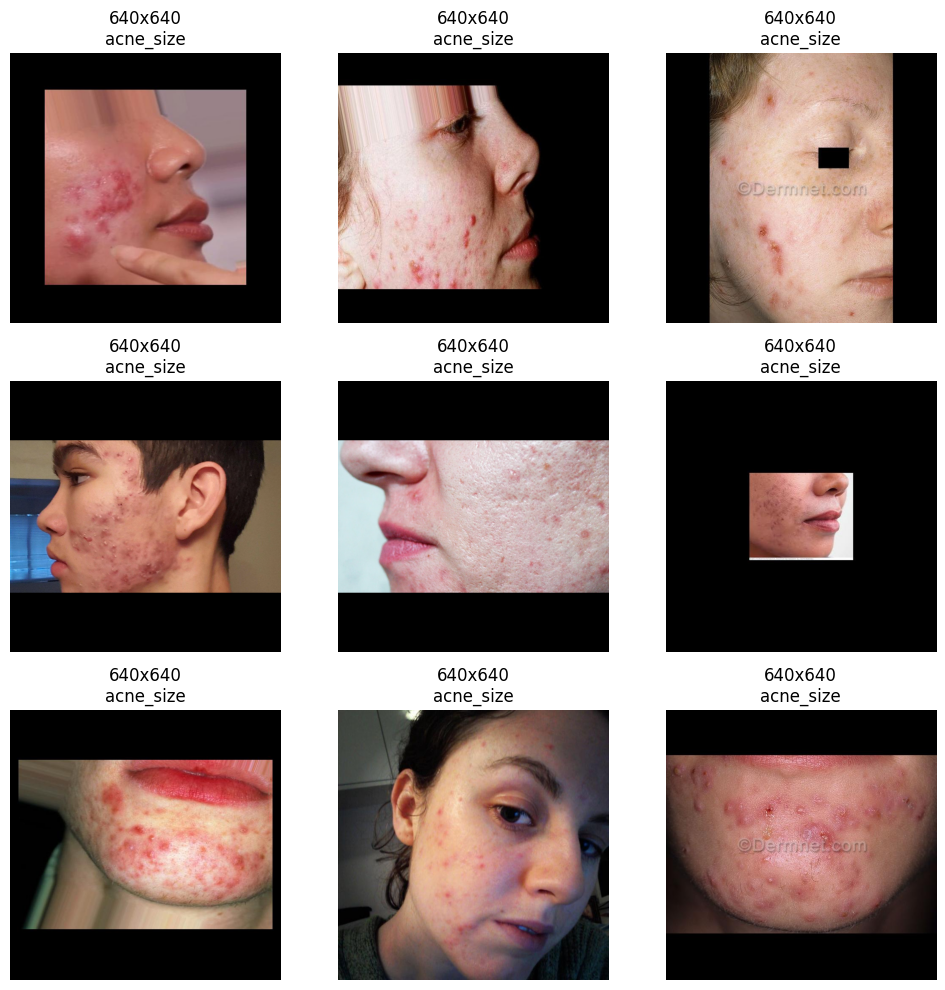

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import random
from pathlib import Path

# Pointe vers ton NOUVEAU dossier
clean_data_dir = Path(r"C:\Users\Mfumu\Documents\skinmatch\data\processed\skin_images\acne_size")

# Récupère toutes les images du nouveau dossier
all_clean_images = list(clean_data_dir.rglob("*.jpg")) + list(clean_data_dir.rglob("*.jpeg")) + list(clean_data_dir.rglob("*.png"))

# Sélectionne 9 images au hasard
sample_images = random.sample(all_clean_images, min(9, len(all_clean_images)))

# Affiche la grille 3x3
plt.figure(figsize=(10, 10))
for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    
    # On affiche la taille pour confirmer que tout est bien en 640x640
    plt.title(f"{img.size[0]}x{img.size[1]}\n{img_path.parent.name}")
    plt.axis("off")

plt.tight_layout()
plt.show()